In [19]:
import os
import glob
import numpy as np
import rasterio
import datetime as dt
from dateutil import tz
import sys
sys.path.append(r"C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like")
#from atmcor.atmospheric_parameters import ATMO_parameter
#from atmcor.cams_data_reader import ECMWF_Product
from atmcor.smac import smac
sys.path.append(r"C:\Users\SamanthaLavender\Documents\GitHub\sen2like\prisma4sen2like\prisma")
from sunpy.coordinates import sun
from spectral_aggregation_functions import radiance_to_reflectance


In [20]:
inpath = r"C:\DDrive\Vega\Proba-reprocessing\Outputs\ReflectanceProducts"
tds = r"Audobon"
infolder = os.path.join(inpath, tds)
files = glob.glob(os.path.join(infolder,"*.tif"))
for f in files:
    if "boa" not in f:
        file = f
        break
print("Found: {}".format(file))

Found: C:\DDrive\Vega\Proba-reprocessing\Outputs\ReflectanceProducts\Audobon\3FB1Image.tif


In [21]:
# Using Landsat 5TM bands while MSS Coeffs generated
ds = rasterio.open(file)
rtoaimg = ds.read().astype(np.float32)
print("Dataset: {}".format(rtoaimg.shape))
nbands = rtoaimg.shape[0]
ds.close()
print("Read in data and applied scaling to radiance: {} {}".format(np.nanmin(rtoaimg),np.nanmax(rtoaimg)))
# remove any unmasked problematic values
rtoaimg[rtoaimg>1.0] = 1.0

Dataset: (18, 748, 744)
Read in data and applied scaling to radiance: 1.401298464324817e-45 8.54542350769043


In [ ]:
# from header file/geometric processing
## Solar zenith and azimuth angles
theta_s = np.deg2rad(28.0)
phi_s = np.deg2rad(107.586944) # This one needs to come from the geometric processing as not in the header file

# View Zenith and Azimuth Angles
theta_v = np.deg2rad(25.92)   
phi_v = np.deg2rad(136.64)  

# Read from WLMID
pbands = [441.9,490.7,530.6,552.0,570.6,632.3,662.2,675.6,698.6,707.6,713.8,743.1,753.4,782.4,874.1,897.4,911.9,1021.3]
print("{} bands".format(len(pbands)))

18 bands


In [23]:
# default params
uH2O = 2.0  # Water Vapor content - unit: g.cm-2
uO3 = 0.331  # Ozone content - unit: cm-atm , 0.3 cm-atm = 300 Dobson Units
pressure = 1013.095  # Pressure - unit: hpa
taup550 = 0.2  # taup550 - unit: unitless


In [24]:
def get_smac_coefficients(sensor,band):
    # format e.g. Coef_MSS5_CONT_B2
    filename = "Coef_{}_CONT_B{}.dat".format(sensor,band)
    if filename is None:
        return None

    # smac coefficient are in the smac package
    smac_directory = os.path.dirname(os.path.abspath(smac.__file__))
    smac_file = os.path.join(smac_directory, 'COEFS', filename)
    if os.path.exists(smac_file):
        return smac_file
    else:
        print("Could not find {}".format(smac_file))
        return None

In [25]:
# Atmospheric parameters retrieve from CAMS :
r_toa = np.arange(101) / 100.
r_surf_SMAC = np.zeros(101)

# # Apply correction
rboaimg = np.zeros((nbands,ds.shape[0],ds.shape[1]), dtype = np.float32)
sensor = "S2A"
if nbands > 12:
    s2bands = [443,490,560,665,705,740,783,842,865]#,945,1375]
    bands = []
    for i in pbands:
        for count,j in enumerate(s2bands):
            if j >= i:
                bands.append(count+1)
                #print("Proba {} Sentinel-2 {}".format(i,j))
                break
    print("Used Sentinel-2 bands: {}".format(bands))
for b,band in enumerate(bands):
    print("Processing band {} {}".format(b,band))
    # Load SMAC coefficients
    coef_file = get_smac_coefficients(sensor, band)
    print(coef_file)
    if coef_file is None:
        raise SystemExit("No smac coefficients for %s", band)
    smac_coefs = smac.coeff(coef_file)

    # Run SMAC for r_toa ranging from 0.0 to 1.0
    for i in range(101):
        r_surf_SMAC[i] = smac.smac_inv(
            r_toa[i], theta_s, phi_s,
            theta_v, phi_v, pressure,
            taup550, uO3, uH2O, smac_coefs)
    #
    # Use a polynomial fit of order 2 to fit relation between surface reflectance and TOA reflectance
    poly_coefs = np.polyfit(r_toa, r_surf_SMAC, 2, full=True)
    if b == 0:
        print("Coeffs: {}".format(poly_coefs))
    
    # Apply fitted relation to convert TOA reflectance to surface reflectance
    sref = poly_coefs[0][2] + poly_coefs[0][1] * rtoaimg[b,:,:] + poly_coefs[0][0] * rtoaimg[b,:,:] ** 2
    mask = (rtoaimg[b,:,:] <= 0)
    mask2 = (sref <= 0)
    sref[mask] = 0
    sref[mask2] = 0
    rboaimg[b,:,:] = sref[:,:]
    print("band {} BOA reflectance: {:.3f} {:.3f}".format(b+1,np.nanmin(rboaimg[b,:,:]),np.nanmax(rboaimg[b,:,:])))


Used Sentinel-2 bands: [1, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7]
Processing band 0 1
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_S2A_CONT_B1.dat
Coeffs: (array([-0.30635515,  1.49230681, -0.15707563]), array([0.00024049]), np.int32(3), array([1.64934844, 0.51943226, 0.09919601]), np.float64(2.2426505097428162e-14))
band 1 BOA reflectance: 0.000 0.454
Processing band 1 3
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_S2A_CONT_B3.dat
band 2 BOA reflectance: 0.043 0.633
Processing band 2 3
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_S2A_CONT_B3.dat
band 3 BOA reflectance: 0.022 0.727
Processing band 3 3
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_S2A_CONT_B3.dat
band 4 BOA reflectance: 0.019 0.465
Processing band 4 4
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\

In [26]:
# Save to Level 2 file
ofile = file.replace(".tif","-boa.tif")
with rasterio.open(files[0]) as src:
    out_meta = src.meta
 
    # Change the band count and data format
    out_meta.update(dtype=rasterio.float32, count=nbands, nodata=0.0)

with rasterio.open(ofile, "w", **out_meta) as dest:
    for i in range(nbands):
        dest.write(rboaimg[i,:,:], i+1)

if os.path.exists(ofile):
    print("Success, generated {}".format(ofile))
else:
    raise SystemExit("Failed to generate L2 file")

Success, generated C:\DDrive\Vega\Proba-reprocessing\Outputs\ReflectanceProducts\Audobon\3FB1Image-boa.tif


Plot written to: MESSR-spectra.png


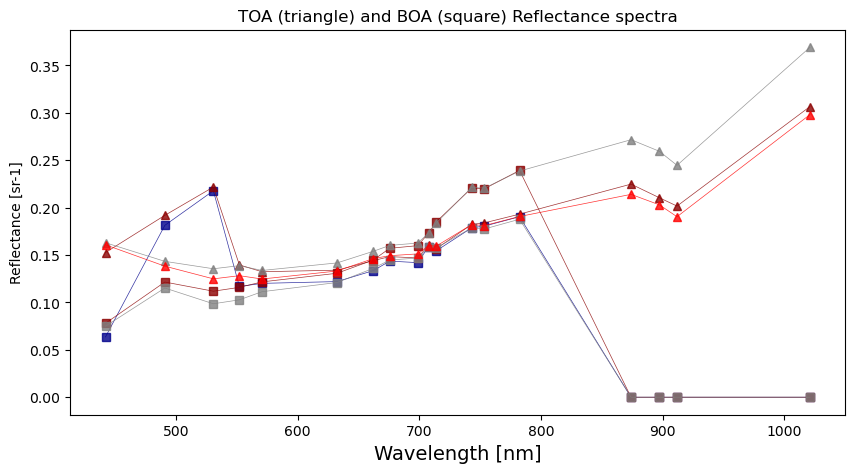

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
%matplotlib inline
# Plot data
plt.figure(figsize=(10,5))
ax = plt.gca()
colorb = np.array(['darkblue','darkred','grey','red','mediumseagreen','blue','pink','darkgreen','teal','pink','cyan','purple','brown'])
pixels = [0,350,700]
for i,pixel in enumerate(pixels):
    ax.plot(pbands, rboaimg[:,pixel,pixel], marker='s', color=colorb[i], lw=0.5, alpha=0.8)
    ax.plot(pbands, rtoaimg[:,pixel,pixel], marker='^', color=colorb[i+1], lw=0.5, alpha=0.8)
plt.title('TOA (triangle) and BOA (square) Reflectance spectra') 
plt.xlabel("Wavelength [nm]",size=14)
ax.set_ylabel("Reflectance [sr-1]")

outfig = 'MESSR-spectra.png'
plt.savefig(outfig, dpi=300, bbox_inches='tight')
print("Plot written to: {}".format(outfig))
plt.show()